In [4]:
import numpy as np
from scipy.linalg import eig

import matplotlib.pyplot as plt

In [5]:
# Define matrix P and Jacobian matrix E= dF(0)/dz at origin
P = np.array([[0.2,0.1,0.05],[0.1,0.3,0.05],[0.05,0.05,0.2]])
D = np.array([[-2,2,0],[2,-2,0],[0,0,0]])
E = - (2*P + D)
e,evecL,evecR = eig(E,left=True)
# eigenvalues
eval1 = e[0].real
eval2 = e[1].real
eval3 = e[2].real
# eigenvectors
w1 = evecL[:,0]
w2 = evecL[:,1]
w3 = evecL[:,2]

In [34]:
eval1, eval2, eval3

(3.7022740717002773, -0.7580943182111134, -0.3441797534891653)

In [35]:
#Define (z_1,z_2) grid

npoints = 20
x_grid = np.linspace(-2, 2, npoints)
y_grid = np.linspace(-2, 2, npoints)
z_grid = np.linspace(-2, 2, npoints)

X,Y,Z = np.meshgrid(x_grid,y_grid, z_grid)
XYZ = np.zeros((npoints**3,3))

k = 0
for i in range(npoints):
    for j in range(npoints):
        for l in range(npoints):
            XYZ[k,:] = np.array([X[i,j,l],Y[i,j,l], Z[i,j,l]])
            k = k+1

In [36]:
#Define functions F and G
def F(x):
    value1 = 2 * x @ P
    
    partial1 = -2 * ( x[:,0] - x[:,1] ) * np.exp( - ( x[:,0] - x[:,1] )**2 )
    partial2 = -partial1
    partial3 = np.zeros((len(partial1),))
    
    value2 = np.array([partial1, partial2, partial3]).T
    return - value1 - value2

# Define the function g using autograd's numpy (jnp)
def G(x):
    value = np.zeros((len(x),3))
    for i in range(len(x)):
        value[i,:] = np.dot(E, x[i,:])
    value = F(x)-value
    return value

In [37]:
# define eigenfunctions
#def phi_1(X):
#    return X[:,0] - X[:,1]**2

#def phi_2(X):
#    return -X[:,0]**2 + X[:,1] + 2 * X[:,0] * X[:,1]**2 - X[:,1] ** 4

In [38]:
# copute F and G at mesh grids
F_val = F(XYZ)
G_val = G(XYZ)

In [39]:
F_val.shape, G_val.shape

((8000, 3), (8000, 3))

#### Eigenfunction $\phi_{\lambda_1}$

In [40]:
# Generate random features
# number of features
N = 1500
# scaling parameter
gamma = 0.000000001
# random feature matrix
Omega = np.random.normal(0, np.sqrt(2*gamma), size=(3,N) )
# random bias
random_bias = np.random.uniform(-np.pi, np.pi, size=(N,))
# temp matrix
A_0 = np.cos(random_bias)
B_0 = np.sin(random_bias)
# generate amtrix A
A = np.zeros((npoints**3+4,N))
A[0,:] = A_0                   # h(0) = 0
A[1:4,:] = B_0 * Omega         # h'(0) = 0
# linear pde
A[4:,:] = - F_val @ Omega * np.sin(XYZ @ Omega + random_bias) - eval1 * np.cos(XYZ @ Omega + random_bias) 

# right-hand side
y0 = np.zeros((4,1))
y1 = np.zeros((npoints**3,1))
for i in range(npoints**3):
    y1[i] = -G_val[i,:] @ w1
y = np.row_stack((y0,y1))

# solve optimization problem
c = np.linalg.pinv(A) @ y
# estimate non-linear function h at mesh grids
K = np.cos(XYZ @ Omega + random_bias)
y_test = K@c

# estimate eigenfunction
phi1_hat = y_test.reshape(npoints, npoints, npoints) + w1[0] * X + w1[1] * Y + w1[2] * Z
# compute true eigenfucntion
#phi1 = phi_1(XY).reshape(npoints,npoints)

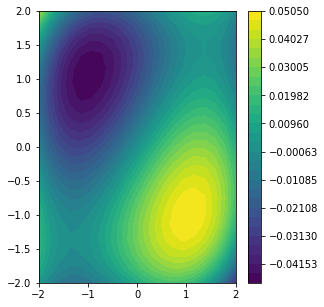

In [41]:
min_val = np.min(phi1_hat[:,:,15]) * 1000
max_val = np.max(phi1_hat[:,:,15]) * 1000

# visualization
plt.subplots(figsize=(15,5))
plt.subplot(1,3,1)
im = plt.contourf(X[:,:,15],Y[:,:,15],phi1_hat[:,:,15]* 1000,levels=np.linspace(min_val,max_val,30))
plt.colorbar(im)

#plt.subplot(1,3,2)
#im = plt.contourf(phi1, levels=np.linspace(-2,1,20))
#plt.colorbar(im, ticks=[0.9, 0.45, 0, -0.45, -0.9, -1.35, -1.8])

#plt.subplot(1,3,3)
#im = plt.imshow(abs(phi1 - phi1_hat))
#plt.colorbar(im, )

#### Eigenfunction $\phi_{\lambda_2}$

In [42]:
# Generate random features
# number of features
N = 1500
# scaling parameter
gamma = 0.000001
# random feature matrix
Omega = np.random.normal(0, np.sqrt(2*gamma), size=(3,N) )
# random bias
random_bias = np.random.uniform(-np.pi, np.pi, size=(N,))
# temp matrix
A_0 = np.cos(random_bias)
B_0 = np.sin(random_bias)
# generate amtrix A
A = np.zeros((npoints**3+4,N))
A[0,:] = A_0                   # h(0) = 0
A[1:4,:] = B_0 * Omega         # h'(0) = 0
# linear pde
A[4:,:] = - F_val @ Omega * np.sin(XYZ @ Omega + random_bias) - eval2 * np.cos(XYZ @ Omega + random_bias) 

# right-hand side
y0 = np.zeros((4,1))
y1 = np.zeros((npoints**3,1))
for i in range(npoints**3):
    y1[i] = -G_val[i,:] @ w2
y = np.row_stack((y0,y1))

# solve optimization problem
c = np.linalg.pinv(A) @ y
# estimate non-linear function h at mesh grids
K = np.cos(XYZ @ Omega + random_bias)
y_test = K@c

# estimate eigenfunction
phi2_hat = y_test.reshape(npoints,npoints,npoints) + w2[0] * X + w2[1] * Y + w2[2] * Z
# compute true eigenfucntion
#phi2 = phi_2(XY).reshape(npoints,npoints)

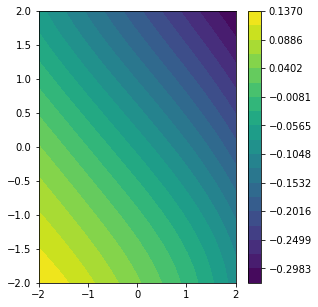

In [43]:
min_val = np.min(phi2_hat[:,:,15]) 
max_val = np.max(phi2_hat[:,:,15]) 

# visualization
plt.subplots(figsize=(15,5))
plt.subplot(1,3,1)
im = plt.contourf(X[:,:,15],Y[:,:,15],phi2_hat[:,:,15],levels=np.linspace(min_val,max_val,20))
plt.colorbar(im)

#plt.subplot(1,3,2)
#im = plt.contourf(phi2, levels=np.linspace(-5,1,20))
#plt.colorbar(im)

#plt.subplot(1,3,3)
#im = plt.imshow(abs(phi2 - phi2_hat))
#plt.colorbar(im)

#### Eigenfunction $\phi_{\lambda_3}$

In [44]:
# Generate random features
# number of features
N = 1500
# scaling parameter
gamma = 0.000001
# random feature matrix
Omega = np.random.normal(0, np.sqrt(2*gamma), size=(3,N) )
# random bias
random_bias = np.random.uniform(-np.pi, np.pi, size=(N,))
# temp matrix
A_0 = np.cos(random_bias)
B_0 = np.sin(random_bias)
# generate amtrix A
A = np.zeros((npoints**3+4,N))
A[0,:] = A_0                   # h(0) = 0
A[1:4,:] = B_0 * Omega         # h'(0) = 0
# linear pde
A[4:,:] = - F_val @ Omega * np.sin(XYZ @ Omega + random_bias) - eval3 * np.cos(XYZ @ Omega + random_bias) 

# right-hand side
y0 = np.zeros((4,1))
y1 = np.zeros((npoints**3,1))
for i in range(npoints**3):
    y1[i] = -G_val[i,:] @ w3
y = np.row_stack((y0,y1))

# solve optimization problem
c = np.linalg.pinv(A) @ y
# estimate non-linear function h at mesh grids
K = np.cos(XYZ @ Omega + random_bias)
y_test = K@c

# estimate eigenfunction
phi3_hat = y_test.reshape(npoints,npoints,npoints) + w3[0] * X + w3[1] * Y + w3[2] * Z
# compute true eigenfucntion
#phi2 = phi_2(XY).reshape(npoints,npoints)

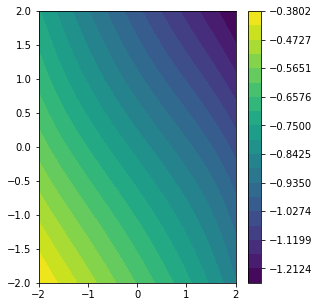

In [45]:
min_val = np.min(phi3_hat[:,:,0]) 
max_val = np.max(phi3_hat[:,:,0]) 

# visualization
plt.subplots(figsize=(15,5))
plt.subplot(1,3,1)
im = plt.contourf(X[:,:,15],Y[:,:,15],phi3_hat[:,:,0],levels=np.linspace(min_val,max_val,20))
plt.colorbar(im)

#plt.subplot(1,3,2)
#im = plt.contourf(phi2, levels=np.linspace(-5,1,20))
#plt.colorbar(im)

#plt.subplot(1,3,3)
#im = plt.imshow(abs(phi2 - phi2_hat))
#plt.colorbar(im)

## Random Points

In [46]:
# Define matrix P and Jacobian matrix E= dF(0)/dz at origin
P = np.array([[0.2,0.1,0.05],[0.1,0.3,0.05],[0.05,0.05,0.2]])
D = np.array([[-2,2,0],[2,-2,0],[0,0,0]])
E = - (2*P + D)
e,evecL,evecR = eig(E,left=True)
# eigenvalues
eval1 = e[0].real
eval2 = e[1].real
eval3 = e[2].real
# eigenvectors
w1 = evecL[:,0]
w2 = evecL[:,1]
w3 = evecL[:,2]

In [47]:
## Define random points from [-2,2]^3
npoints = 4000
XYZ = np.random.uniform(-2,2,size=(npoints,3))

# copute F and G at mesh grids
F_val = F(XYZ)
G_val = G(XYZ)

In [48]:
# Generate random features
# number of features
N = 1500
# scaling parameter
gamma = 0.0000003
# random feature matrix
Omega = np.random.normal(0, np.sqrt(2*gamma), size=(3,N) )
# random bias
random_bias = np.random.uniform(-np.pi, np.pi, size=(N,))
# temp matrix
A_0 = np.cos(random_bias)
B_0 = np.sin(random_bias)
# generate amtrix A
A = np.zeros((npoints+4,N))
A[0,:] = A_0                   # h(0) = 0
A[1:4,:] = B_0 * Omega         # h'(0) = 0
# linear pde
A[4:,:] = - F_val @ Omega * np.sin(XYZ @ Omega + random_bias) - eval1 * np.cos(XYZ @ Omega + random_bias) 

# right-hand side
y0 = np.zeros((4,1))
y1 = np.zeros((npoints,1))
for i in range(npoints):
    y1[i] = -G_val[i,:] @ w1
y = np.row_stack((y0,y1))

# solve optimization problem
c = np.linalg.pinv(A) @ y

In [49]:
npoints = 20
x_grid = np.linspace(-2, 2, npoints)
y_grid = np.linspace(-2, 2, npoints)
z_grid = np.linspace(-2, 2, npoints)

X,Y,Z = np.meshgrid(x_grid,y_grid, z_grid)
XYZ_test = np.zeros((npoints**3,3))

k = 0
for i in range(npoints):
    for j in range(npoints):
        for l in range(npoints):
            XYZ_test[k,:] = np.array([X[i,j,l],Y[i,j,l], Z[i,j,l]])
            k = k+1


# estimate non-linear function h at mesh grids
K = np.cos(XYZ_test @ Omega + random_bias)
y_test = K@c

# estimate eigenfunction
phi1_hat = y_test.reshape(npoints, npoints, npoints) + w1[0] * X + w1[1] * Y + w1[2] * Z


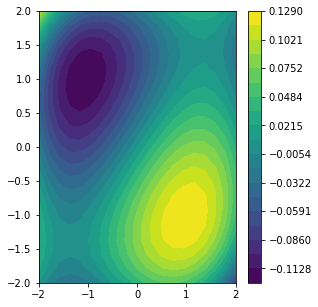

In [50]:
min_val = np.min(phi1_hat[:,:,10]) * 1000
max_val = np.max(phi1_hat[:,:,10]) * 1000

# visualization
plt.subplots(figsize=(15,5))
plt.subplot(1,3,1)
im = plt.contourf(X[:,:,15],Y[:,:,15],phi1_hat[:,:,10]* 1000,levels=np.linspace(min_val,max_val,20))
plt.colorbar(im)

#plt.subplot(1,3,2)
#im = plt.contourf(phi1, levels=np.linspace(-2,1,20))
#plt.colorbar(im, ticks=[0.9, 0.45, 0, -0.45, -0.9, -1.35, -1.8])

#plt.subplot(1,3,3)
#im = plt.imshow(abs(phi1 - phi1_hat))
#plt.colorbar(im, )

In [61]:
# estimate at z=0.14
npoints = 20
x_grid = np.linspace(-2, 2, npoints)
y_grid = np.linspace(-2, 2, npoints)
z_grid = np.linspace(-2, 2, npoints)

X,Y = np.meshgrid(x_grid,y_grid)
XYZ_test = np.zeros((npoints**2,3))

k = 0
for i in range(npoints):
    for j in range(npoints):
            XYZ_test[k,:] = np.array([X[i,j],Y[i,j], 0.14])
            k = k+1


# estimate non-linear function h at mesh grids
K = np.cos(XYZ_test @ Omega + random_bias)
y_test = K@c

# estimate eigenfunction
phi1_hat = y_test.reshape(npoints, npoints) + w1[0] * X + w1[1] * Y + w1[2] * 0.14


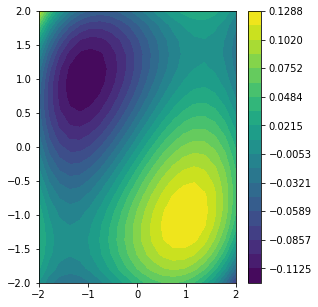

In [62]:
min_val = np.min(phi1_hat) * 1000
max_val = np.max(phi1_hat) * 1000

# visualization
plt.subplots(figsize=(15,5))
plt.subplot(1,3,1)
im = plt.contourf(X,Y,phi1_hat* 1000,levels=np.linspace(min_val,max_val,20))
plt.colorbar(im)

#plt.subplot(1,3,2)
#im = plt.contourf(phi1, levels=np.linspace(-2,1,20))
#plt.colorbar(im, ticks=[0.9, 0.45, 0, -0.45, -0.9, -1.35, -1.8])

#plt.subplot(1,3,3)
#im = plt.imshow(abs(phi1 - phi1_hat))
#plt.colorbar(im, )